In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.datasets import load_iris

import math

In [51]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

target = 'species'
remove_cols = ['']
features = [col for col in df.columns if col != target and col not in remove_cols]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42)
}
scores = {}
for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(X_train, y_train)
    scores[name] = model.score(X_test, y_test)

Fitting Logistic Regression...
Fitting Random Forest...
Fitting Support Vector Machine (SVM)...


In [53]:
for name, score in scores.items():
    print(f"{name} Accuracy: {score:.4f}")
    print("-" * 30)

best_model_name = max(scores, key=scores.get) # || "Random Forest"
best_model = models[best_model_name]
print(f"\nBest performing model: {best_model_name}")

Logistic Regression Accuracy: 1.0000
------------------------------
Random Forest Accuracy: 1.0000
------------------------------
Support Vector Machine (SVM) Accuracy: 1.0000
------------------------------

Best performing model: Logistic Regression


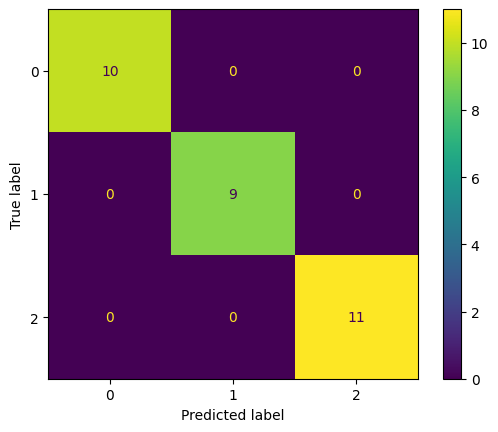

In [54]:
y_pred = best_model.predict(X_test)

class_names = np.unique(iris.target)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [55]:
import pickle

with open('best_model - iris.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
data_to_predict = pd.DataFrame([
    {'sepal length (cm)': 4.7, 'sepal width (cm)': 3.2, 'petal length (cm)': 1.3, 'petal width (cm)': 0.2},
    {'sepal length (cm)': 3, 'sepal width (cm)': 4.6, 'petal length (cm)': 4.6, 'petal width (cm)': 1.5	},
    {'sepal length (cm)': 15, 'sepal width (cm)': 4.6, 'petal length (cm)': 3.1, 'petal width (cm)': 2.5	},
    {'sepal length (cm)': 1, 'sepal width (cm)': 2.5, 'petal length (cm)': 10, 'petal width (cm)': 4.5	},
])

predictions = best_model.predict(data_to_predict)

for sl, sw, pl, pw, prediction in zip(data_to_predict['sepal length (cm)'], data_to_predict['sepal width (cm)'], data_to_predict['petal length (cm)'], data_to_predict['petal width (cm)'], predictions):
    print(f"The Iris with {sl} sepal length (cm), {sw} sepal width (cm), {pl} petal length (cm), {pw} petal width is..:")
    print(f" - {prediction}")


The Iris with 4.7 sepal length (cm), 3.2 sepal width (cm), 1.3 petal length (cm), 0.2 petal width is..:
 - 0
The Iris with 3.0 sepal length (cm), 4.6 sepal width (cm), 4.6 petal length (cm), 1.5 petal width is..:
 - 2
The Iris with 15.0 sepal length (cm), 4.6 sepal width (cm), 3.1 petal length (cm), 2.5 petal width is..:
 - 1
The Iris with 1.0 sepal length (cm), 2.5 sepal width (cm), 10.0 petal length (cm), 4.5 petal width is..:
 - 2
